# **XGBoost** классификация


это реализация градиентного бустинга над деревьями решений с регуляризацией, которая последовательно добавляет новые деревья, уменьшая ошибку предыдущих и тем самым строя сильную модель из множества слабых.


## Предобработка

In [10]:
tr = "classification"
md = "XGBoost"
st = "train_test"
name = "GOLD"

In [1]:
import sys, os
sys.path.append(os.path.abspath("../.."))

In [2]:
import pandas as pd
from data_preprocessing.DataForModel import build_target, split_data, preprocess_dataset, append_results

In [11]:
df: pd.DataFrame = pd.read_csv(f"/Users/side/Desktop/Trading Chaos AI/df/clean_df/{name}.csv")

In [4]:
df = preprocess_dataset(df)

In [17]:
df = build_target(df, h=20, target_type=tr)

y = df["GoodTrade"]

In [ ]:
X_train, X_test, y_train, y_test = split_data(df, target="GoodTrade", val_size=0.1, test_size=0.2, split_type=st)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (29088, 33), X_test: (7272, 33)


## Обучение

In [12]:
import xgboost as xgb
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

Количество классов:
GoodTrade
0    35463
1      897
Name: count, dtype: int64 

Процент классов:
GoodTrade
0    97.533003
1     2.466997
Name: proportion, dtype: float64


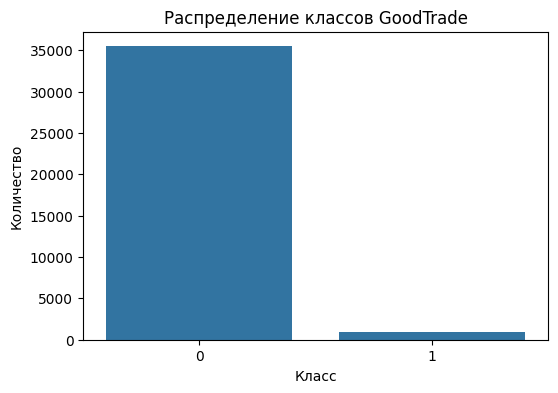

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Проверим распределение классов
class_counts = df["GoodTrade"].value_counts()
class_percent = df["GoodTrade"].value_counts(normalize=True) * 100

print("Количество классов:")
print(class_counts, "\n")

print("Процент классов:")
print(class_percent)

# Визуализация
plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Распределение классов GoodTrade")
plt.xlabel("Класс")
plt.ylabel("Количество")
plt.show()

In [8]:
model = xgb.XGBClassifier(eval_metric="logloss")

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9998624862486248

In [13]:
# Предикты
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # для ROC-AUC

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Вычислим метрики
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)

Precision: 1.0
Recall: 0.9949748743718593
F1-score: 0.9974811083123426
ROC-AUC: 1.0


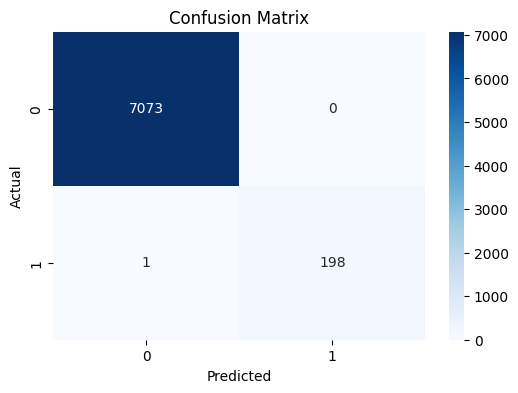

In [14]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7073
           1       1.00      0.99      1.00       199

    accuracy                           1.00      7272
   macro avg       1.00      1.00      1.00      7272
weighted avg       1.00      1.00      1.00      7272



In [ ]:
results = {
    "model": md,
    "target_type": tr,
    "accuracy": accuracy
}

results_df = pd.DataFrame([results])
results_df.to_csv(f"/Users/side/Desktop/Trading Chaos AI/df/results/Results.csv", index=False)

настройка баланса классов

In [19]:
results = {
    "model": "XGBoost",
    "task": "classification",
    "horizon": 20,
    "accuracy": accuracy
}

append_results(results)

Results appended to /Users/side/Desktop/Trading Chaos AI/df/results/Results.csv
